In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Install dependencies
!pip install torch torchvision scikit-learn matplotlib seaborn -q

In [4]:
# Imports
import numpy as np
import json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Load data
BASE = "/content/drive/MyDrive/signverse-ml"

X_train = np.load(f"{BASE}/X_train_aug.npy")
y_train = np.load(f"{BASE}/y_train_aug.npy")
X_val   = np.load(f"{BASE}/X_val.npy")
y_val   = np.load(f"{BASE}/y_val.npy")
X_test  = np.load(f"{BASE}/X_test.npy")
y_test  = np.load(f"{BASE}/y_test.npy")

with open(f"{BASE}/label_map.json") as f:
    label_map = json.load(f)

NUM_CLASSES = len(label_map)
print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")
print(f"Classes: {NUM_CLASSES}")

Train : (140400, 63)
Val   : (10029, 63)
Test  : (10029, 63)
Classes: 29


In [5]:
# Create Pytorch datasets
# Convert to tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)
X_val_t   = torch.FloatTensor(X_val)
y_val_t   = torch.LongTensor(y_val)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.LongTensor(y_test)

# Create datasets and loaders
train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t,   y_val_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=256)
test_loader  = DataLoader(test_ds,  batch_size=256)

print("Dataloaders ready.")

Dataloaders ready.


In [6]:
#Define the model
class AlphabetClassifier(nn.Module):
    def __init__(self, input_size=63, num_classes=29):
        super().__init__()
        self.net = nn.Sequential(
            # Layer 1
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 2
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 3
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Layer 4
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Output
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = AlphabetClassifier(input_size=63, num_classes=NUM_CLASSES).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda
Parameters: 318,237


In [7]:
#Training setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=5, factor=0.5
)

EPOCHS = 50
best_val_acc = 0
best_model_state = None
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

In [8]:
#Training loop
for epoch in range(EPOCHS):
    # ── Train ──────────────────────────────────────────
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == y_batch).sum().item()
        train_total   += len(y_batch)

    train_acc  = train_correct / train_total
    train_loss = train_loss / len(train_loader)

    # ── Validate ───────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs    = model(X_batch)
            loss       = criterion(outputs, y_batch)
            val_loss  += loss.item()
            preds      = outputs.argmax(dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total  += len(y_batch)

    val_acc  = val_correct / val_total
    val_loss = val_loss / len(val_loader)

    # ── Scheduler + save best ─────────────────────────
    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        print(f"  ✓ New best model saved (val_acc={val_acc:.4f})")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

  ✓ New best model saved (val_acc=0.9435)
Epoch   1/50 | Train Loss: 0.5522 | Train Acc: 0.8526 | Val Loss: 0.1764 | Val Acc: 0.9435
  ✓ New best model saved (val_acc=0.9653)
Epoch   2/50 | Train Loss: 0.2004 | Train Acc: 0.9400 | Val Loss: 0.1215 | Val Acc: 0.9653
Epoch   3/50 | Train Loss: 0.1669 | Train Acc: 0.9496 | Val Loss: 0.3312 | Val Acc: 0.9170
Epoch   4/50 | Train Loss: 0.1471 | Train Acc: 0.9553 | Val Loss: 0.1337 | Val Acc: 0.9584
  ✓ New best model saved (val_acc=0.9687)
Epoch   5/50 | Train Loss: 0.1364 | Train Acc: 0.9585 | Val Loss: 0.1044 | Val Acc: 0.9687
  ✓ New best model saved (val_acc=0.9798)
Epoch   6/50 | Train Loss: 0.1292 | Train Acc: 0.9611 | Val Loss: 0.0728 | Val Acc: 0.9798
Epoch   7/50 | Train Loss: 0.1208 | Train Acc: 0.9638 | Val Loss: 0.0756 | Val Acc: 0.9783
Epoch   8/50 | Train Loss: 0.1159 | Train Acc: 0.9647 | Val Loss: 0.1111 | Val Acc: 0.9662
  ✓ New best model saved (val_acc=0.9804)
Epoch   9/50 | Train Loss: 0.1109 | Train Acc: 0.9658 | Val Lo

In [9]:
#Evaluate on test set
# Load best model
model.load_state_dict(best_model_state)
model.eval()

test_correct, test_total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        preds   = outputs.argmax(dim=1)
        test_correct += (preds == y_batch).sum().item()
        test_total   += len(y_batch)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

test_acc = test_correct / test_total
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

Test Accuracy: 0.9915 (99.15%)


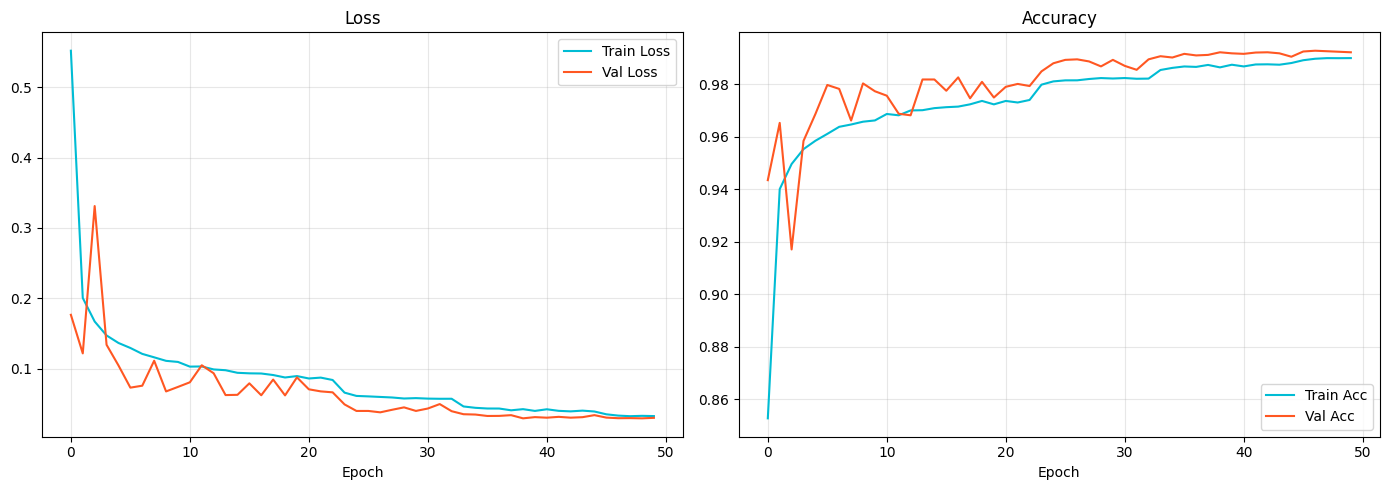

Saved training curves.


In [10]:
#Plot training curves
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train Loss", color="#00BCD4")
ax1.plot(history["val_loss"],   label="Val Loss",   color="#FF5722")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history["train_acc"], label="Train Acc", color="#00BCD4")
ax2.plot(history["val_acc"],   label="Val Acc",   color="#FF5722")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{BASE}/alphabet_training_curves.png", dpi=150)
plt.show()
print("Saved training curves.")

In [12]:
#Save the model
import os

# Save PyTorch model
torch.save({
    "model_state_dict": best_model_state,
    "model_config": {"input_size": 63, "num_classes": NUM_CLASSES},
    "val_accuracy": best_val_acc,
    "test_accuracy": test_acc,
    "label_map": label_map,
}, f"{BASE}/alphabet_model.pth")

print(f"Model saved to Google Drive.")
print(f"Val  accuracy : {best_val_acc*100:.2f}%")
print(f"Test accuracy : {test_acc*100:.2f}%")

Model saved to Google Drive.
Val  accuracy : 99.28%
Test accuracy : 99.15%
